 <div dir="rtl" style="text-align: right;">

 #  פרויקט סימולציה קבוצה 55
  <div dir="rtl" style="text-align: right; font-size: 16px;">
 בפרויקט זה נבצע סימולציה של פעילות יומיומית בלונה פארק. הפארק כולל מגוון תחנות כגון קופות, מתקני אקסטרים, מתקנים משפחתיים ואזורי מזון, דרכן עוברים המבקרים בהתאם לסוגם ודפוסי ההתנהגות שלהם. במסגרת הפרויקט נדגים שימוש באלגוריתמים שונים לדגימה מהתפלגויות הסתברותיות, וננתח את השפעתם של משתנים כמו זמני המתנה, עומס על מתקנים, ואורכי תורים.

 <div dir="rtl" style="text-align: right; font-size: 16px;">
לאחר בניית המודל הבסיסי, נבחן מספר חלופות אפשריות לשיפור התנהלות הפארק, כולן במסגרת מגבלת תקציב של 100,000$. נבצע הרצות סימולציה שונות לכל חלופה, נשווה את תוצאותיהן לפי מדדים שנבחר, ונבחן האם קיימת מובהקות סטטיסטית לשיפור שהושג. לבסוף, נמליץ על החלופה האפקטיבית ביותר לשיפור חוויית המבקר והתייעלות תפעולית של הפארק.


מאחלים לכם יום קסום בלונה פארק! 🎠
</div>

<div dir="rtl" style="text-align: right;">

 #  התאמת התפלגות למודל



 <div dir="rtl" style="text-align: right; font-size: 16px;">

בחלק זה נבחר את סוגי ההתפלגויות המתאימות לרכיבי הזמן המרכזיים במודל - כמו זמני הגעה של מבקרים, זמני שירות בקופות, זמן שהיה במתקנים וזמן אכילה. ההתפלגויות נבחרו על סמך נתונים קיימים או היגיון תפעולי, תוך התאמה לסוג הפעולה הנמדדת (למשל: אקספוננציאלית להגעות, נורמלית לזמני שירות).

במקרים הרלוונטיים ביצענו התאמה של פרמטרים סטטיסטיים (כגון תוחלת וסטיית תקן), ונעזרנו במבחני התאמה בסיסיים כדי לוודא שההתפלגות מתאימה לתרחיש אותו אנו מדמים.
</div>

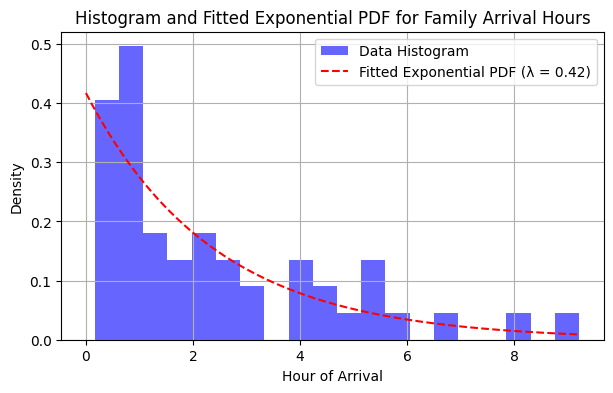

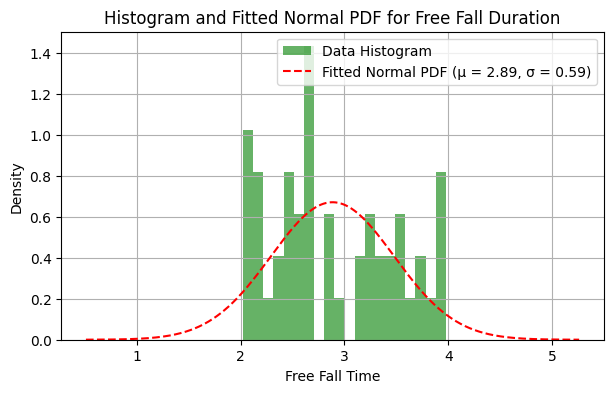

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import probplot
import pandas as pd
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

file_id = '1BsYvrbUMzxYWEJEmA157_-JIGd_7QrVj'
url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv'  # File is stored in Google Drive with public access for direct reading
data = pd.read_csv(url)

### Families ###
column_family_arrival_hours = pd.to_datetime(data['שעות הגעה משפחות'], format='%H:%M:%S', errors='coerce')  # Import arrival hour column from Excel
column_family_arrival_hours = column_family_arrival_hours.dropna()  # Remove invalid entries
column_family_arrival_hours = column_family_arrival_hours.sort_values()
arrival_times = column_family_arrival_hours.diff().dt.total_seconds().dropna() / 60
arrival_diffs_minutes = arrival_times.to_numpy()  # Array of time differences between family arrivals (in minutes)

lambda_mle_family = 1 / np.mean(arrival_diffs_minutes)  # Estimate λ for exponential distribution (MLE)

x = np.linspace(0, np.max(arrival_diffs_minutes), 1000)  # X-axis values for plotting the fitted distribution
pdf_fitted = lambda_mle_family * np.exp(-lambda_mle_family * x)  # Exponential PDF with estimated λ

plt.figure(figsize=(7, 4))  # Plot histogram
plt.hist(arrival_diffs_minutes, bins=20, density=True, alpha=0.6, color='b', label='Data Histogram')
plt.plot(x, pdf_fitted, 'r--', label='Fitted Exponential PDF (λ = {:.2f})'.format(lambda_mle_family))  # Overlay fitted exponential PDF

# Family arrival chart labels
plt.title('Histogram and Fitted Exponential PDF for Family Arrival Hours')
plt.xlabel('Hour of Arrival')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()  # Show plot

### Free Fall ###
column_free_fall_duration = data['זמן נפילה חופשית'].to_numpy()

mu = np.mean(column_free_fall_duration)  # Mean
sigma = np.std(column_free_fall_duration)  # Standard deviation

x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)  # X-axis values for normal distribution plot range

pdf_norm = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_norm - mu) / sigma) ** 2)  # Normal distribution PDF formula

plt.figure(figsize=(7, 4))  # Plot histogram
plt.hist(column_free_fall_duration, bins=20, density=True, alpha=0.6, color='g', label='Data Histogram')
plt.plot(x_norm, pdf_norm, 'r--', label='Fitted Normal PDF (μ = {:.2f}, σ = {:.2f})'.format(mu, sigma))  # Overlay fitted normal PDF

# Free fall duration chart labels
plt.title('Histogram and Fitted Normal PDF for Free Fall Duration')
plt.xlabel('Free Fall Time')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 16px;">

**זמני הגעת משפחות:**

לאחר ניתוח הנתונים באמצעות ההיסטוגרמה, ניתן לראות שמרבית המשפחות מגיעות בשעות המוקדמות, וההסתברות להגעה פוחתת ככל שחולף הזמן. תבנית זו אופיינית להתפלגות אקספוננציאלית, שבה הסיכוי לאירוע הולך ופוחת עם הזמן.
בגרף ניתן לראות התאמה ויזואלית בין ההיסטוגרמה של הנתונים לבין פונקציית הצפיפות של ההתפלגות האקספוננציאלית שהתאמנו לערכים (λ = 0.42) עם זאת, התאמה חזותית בלבד לא מספיקה כדי לקבוע האם הנתונים אכן מתפלגים אקספוננציאלית.
לכן, בשלב הבא נבצע מבחני התאמה סטטיסטיים, במטרה לבדוק האם ההתפלגות האקספוננציאלית אכן מייצגת את התפלגות זמני ההגעה, ולא ניתן לדחות את ההשערה על כך.


---


**זמן נפילה חופשית:**

במקרה של נתוני זמן נפילה חופשית, ההיסטוגרמה מציגה התפלגות שמתכנסת סביב ערך מרכזי, כאשר רוב המדידות מתרכזות בטווח צר ורק מעט מהן נמצא בקצוות. תבנית זו מאפיינת התפלגות נורמלית.
בגרף ניתן לראות התאמה ויזואלית טובה בין הנתונים לבין פונקציית הצפיפות של ההתפלגות הנורמלית שהתאמנו לערכי. (μ = 2.89, σ = 0.59) עם זאת, בדומה למקרה הקודם, התאמה חזותית בלבד אינה מהווה הוכחה.
לכן, נמשיך בביצוע מבחני התאמה סטטיסטיים שיבחנו האם ניתן להניח שהתפלגות זמן הנפילה החופשית אכן נובעת מהתפלגות נורמלית, או שמא יש לדחות את ההשערה הזו.
</div>

In [ ]:
from scipy.special import erf

### Family Arrival Times-KS Test ###

print("*** Kolmogorov-Smirnov Test for Family Arrival Times ***")

def empirical_cdf(data):  # Construct empirical CDF
    data_sorted = np.sort(data)
    n = len(data_sorted)
    return data_sorted, np.arange(1, n + 1) / n

def exp_cdf(x, lambda_):  # Define theoretical exponential CDF
    return 1 - np.exp(-lambda_ * x)

def ks_test(data, cdf_func, *params):  # Compute KS statistic (D)
    data_sorted, empirical_cdf_vals = empirical_cdf(data)
    theoretical_cdf_vals = cdf_func(data_sorted, *params)
    d_max = np.max(np.abs(empirical_cdf_vals - theoretical_cdf_vals))  # Max difference between empirical and theoretical CDF
    return d_max

d_max1 = ks_test(arrival_diffs_minutes, exp_cdf, lambda_mle_family)  # Max gap between empirical and theoretical exponential CDF
n1 = len(arrival_diffs_minutes)  # Sample size
d_statistic1 = (d_max1 - 0.2 / n1) * (n1 ** 0.5 + 0.26 + 0.5 / (n1 ** 0.5))  # Adjusted D-statistic based on KS critical value formula
critic = 1.094  # Critical value from KS table for alpha=5%

print(f"KS Statistic (from scratch): {d_statistic1}")  # Print KS statistic result

if d_statistic1 < critic:
    print("✓ Fail to reject the null hypothesis (H0). The arrival time data fits the exponential distribution.")
else:
    print("✗ Reject the null hypothesis (H0). The arrival time data does not fit the exponential distribution.")

### Free Fall Duration - KS Test ###

print("\n*** Kolmogorov-Smirnov Test for Free Fall Duration ***")

def normal_cdf(x, mu_, sigma_):  # Define theoretical normal CDF
    return 0.5 * (1 + erf((x - mu_) / (sigma_ * np.sqrt(2))))

d_max2 = ks_test(column_free_fall_duration, normal_cdf, mu, sigma)  # Theoretical CDF is normal
n2 = len(column_free_fall_duration)  # Number of observations
d_statistic2 = (d_max2 - 0.2 / n2) * (n2 ** 0.5 + 0.26 + 0.5 / (n2 ** 0.5))  # Adjusted D-statistic based on KS critical value formula

print(f"KS Statistic (from scratch): {d_statistic2}")  # Print KS statistic result

if d_statistic2 < critic:
    print("✓ Fail to reject the null hypothesis (H0). The free fall duration data fits the normal distribution.")
else:
    print("✗ Reject the null hypothesis (H0). The free fall duration data does not fit the normal distribution.")


*** Kolmogorov-Smirnov Test for Family Arrival Times ***
KS Statistic (from scratch): 0.5512282174327855
✓ Fail to reject the null hypothesis (H0). The arrival time data fits the exponential distribution.

*** Kolmogorov-Smirnov Test for Free Fall Duration ***
KS Statistic (from scratch): 1.0180809852716561
✓ Fail to reject the null hypothesis (H0). The free fall duration data fits the normal distribution.


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 16px;">

**התאמה חזותית באמצעות QQ-Plot**

אחרי שביצענו את מבחן קולמוגורוב-סמירנוב לשני המשתנים שנבדקו (זמני ההגעה של המשפחות וזמני הנפילה החופשית) מצאנו כי בשני המקרים לא ניתן לדחות את השערת האפס. כלומר, אין עדות סטטיסטית לכך שהנתונים לא מתפלגים בהתאם להתפלגויות התאורטיות שנבדק (אקספוננציאלית ונורמאלית).

עם זאת, מבחן KS מספק רק מענה מספרי, ואינו מציג את אופן הסטייה או את התחומים שבהם היא מתרחשת. לכן, נציג גם תרשימי QQ-Plot (Quantile-Quantile Plot) עבור 2 המשתנים. תרשימים אלו מאפשרים לנו לבחון בצורה חזותית את מידת ההתאמה בין הנתונים לבין ההתפלגות התאורטית, ולזהות חריגות מקומיות כמו למשל סטיות בקצוות (זנבות) או באזורים המרכזיים של ההתפלגות.
</div>


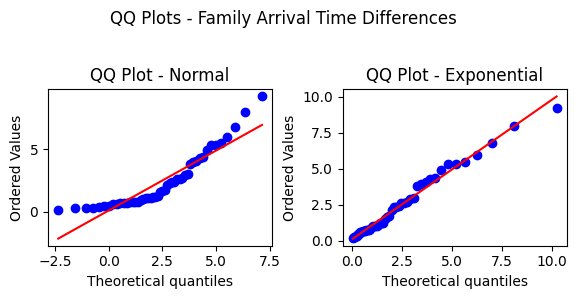

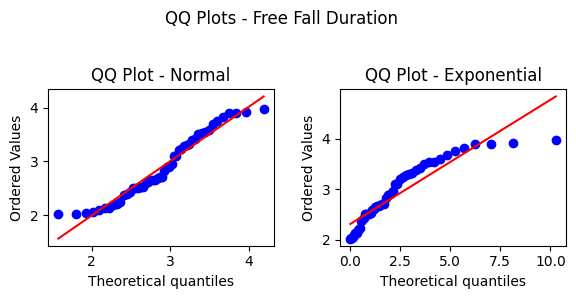

In [ ]:
from scipy.stats import probplot

### QQ Plots-Family Arrival Time Differences ###
plt.figure(figsize=(6, 3))
plt.suptitle("QQ Plots - Family Arrival Time Differences")

plt.subplot(1, 2, 1)  # Comparison to normal distribution
probplot(arrival_diffs_minutes, dist="norm", sparams=(np.mean(arrival_diffs_minutes), np.std(arrival_diffs_minutes)), plot=plt)
plt.title("QQ Plot - Normal")

plt.subplot(1, 2, 2)  # Comparison to exponential distribution
probplot(arrival_diffs_minutes, dist="expon", sparams=(0, 1/lambda_mle_family), plot=plt)
plt.title("QQ Plot - Exponential")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### QQ Plots-Free Fall Duration ###
plt.figure(figsize=(6, 3))
plt.suptitle("QQ Plots - Free Fall Duration")

plt.subplot(1, 2, 1)  # Comparison to normal distribution
probplot(column_free_fall_duration, dist="norm", sparams=(np.mean(column_free_fall_duration), np.std(column_free_fall_duration)), plot=plt)
plt.title("QQ Plot - Normal")

plt.subplot(1, 2, 2)  # Comparison to exponential distribution
probplot(column_free_fall_duration, dist="expon", sparams=(0, 1/lambda_mle_family), plot=plt)
plt.title("QQ Plot - Exponential")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 16px;">

בהתבסס על כל הבדיקות שביצענו (גם מבחני Kolmogorov-Smirnov וגם תרשימי QQ-Plot)  אפשר להסיק:

•	**ההפרשים בין זמני ההגעה של המשפחות** מתאימים
להתפלגות אקספוננציאלית. מבחן KS הראה שאין סיבה לדחות
את ההשערה שהנתונים מתפלגים בצורה כזו, וגם התרשים החזותי מראה התאמה טובה בין הנתונים לבין הקו התאורטי. קצב ההגעה הממוצע לפי החישובים שלנו הוא λ = 0.42.

•	**זמני הנפילה החופשית** מתאימים להתפלגות נורמלית. גם כאן, מבחן KS אישר שההתפלגות התאורטית מתאימה לנתונים, וה־QQ Plot הראה שהנקודות מסתדרות בצורה יפה סביב הקו הישר. הממוצע של זמני הנפילה היה  μ = 2.89, וסטיית התקן σ = 0.59.
בסך הכול, הבדיקות שעשינו תומכות בכך שלכל משתנה מתאימה התפלגות שונה- אקספוננציאלית למשפחות, ונורמלית לזמן הנפילה החופשית.
</div>


<div dir="rtl" style="text-align: right;">

 #  אלגוריתמי דגימה



<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##אלגוריתמי דגימה לפונקציות הלא מוכרות, ופירוט החישובים


</div>



 <div dir="rtl" style="text-align: right;">


**משך שייט - אבובים בנהר**

בחלק זה נבנה אלגוריתם דגימה עבור משך זמן השייט באבובים על פי פונקציית הצפיפות הבאה:

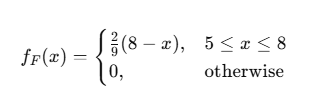

נבצע את חישוב אלגוריתם הדגימה בשיטת טרנפורם הופכי.



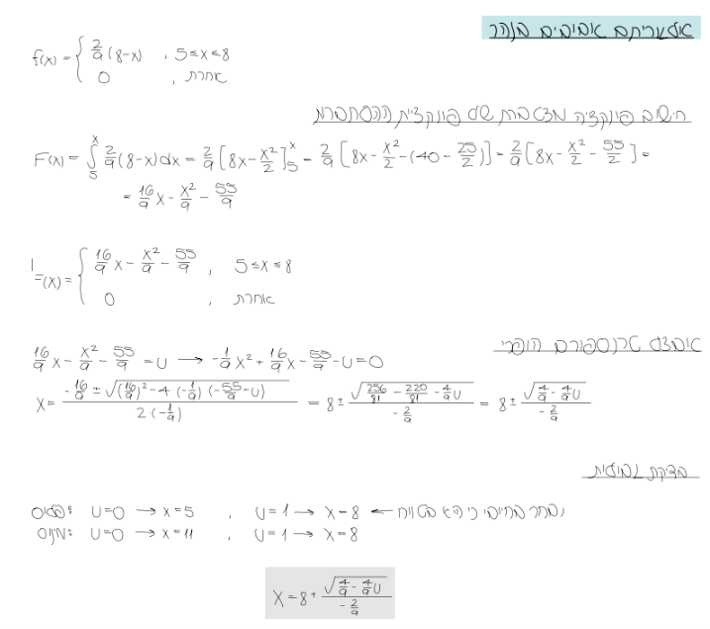

 <div dir="rtl" style="text-align: right;">

**משך מתקן - גלגל ענק**

בחלק זה נבנה אלגוריתם דגימה עבור משך זמן המתקן של גלגל ענק על פי פונקציית הצפיפות הבאה:
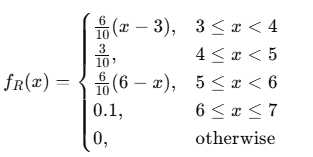

נבצע את חישוב אלגוריתם הדגימה בשיטת טרנפורם הופכי.




 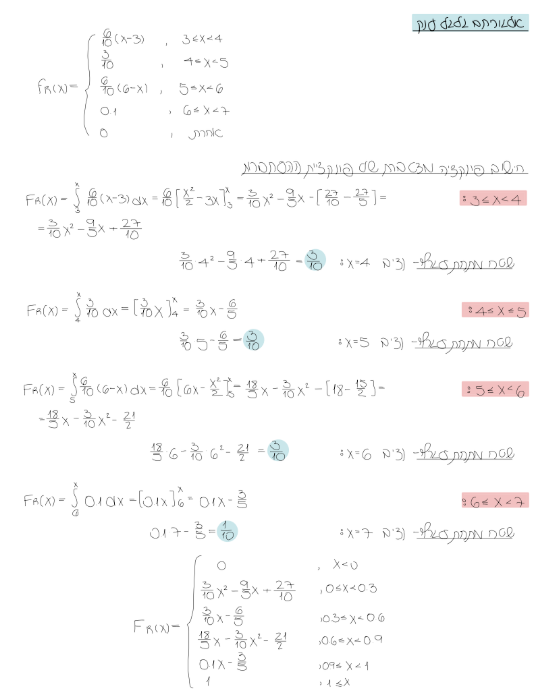

 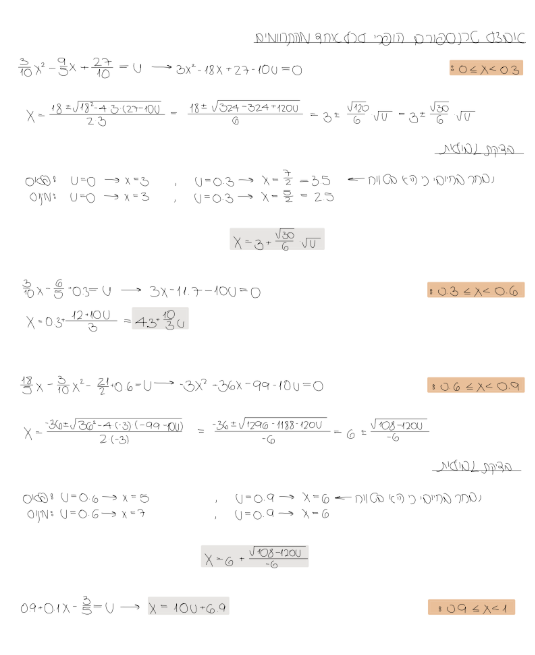




<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##אלגוריתמי דגימה לפונקציות המוכרות, ופירוט החישובים


</div>





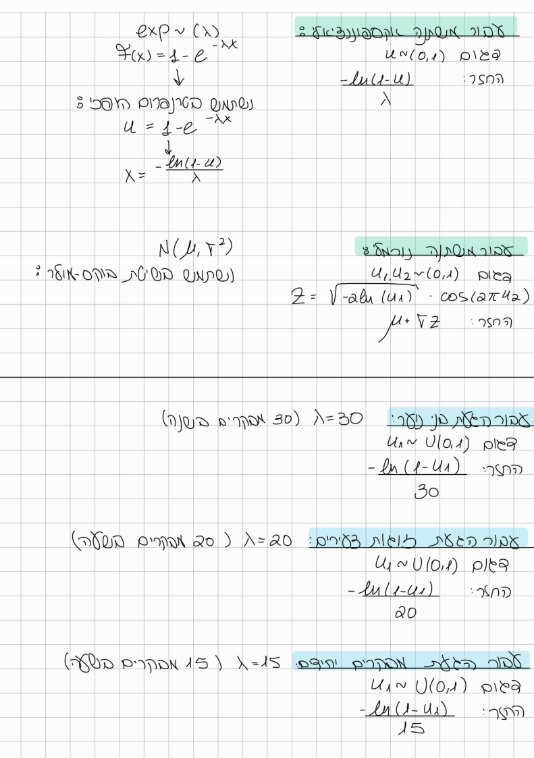

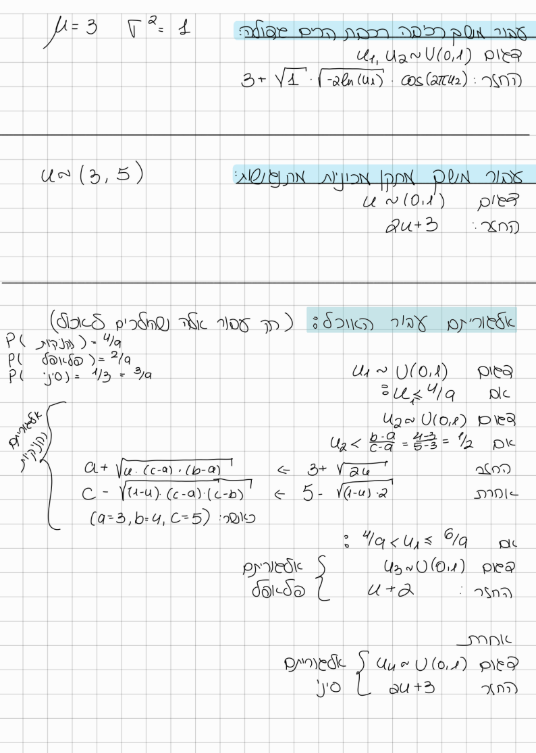

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##מחלקת אלגוריתמים


</div>



In [ ]:
import random
import math

class Sampler:
    def UniformSamplingAlgorithm(self, start, end):
        u = random.random()
        x = start + (end - start) * u
        return x

    def ExponentialSamplingAlgorithm(self, lambda_param):  # Exponential sampling algorithm
        if lambda_param == 0:
            return 0
        else:
            u = random.random()
        return -math.log(1 - u) / lambda_param

    def NormalSamplingAlgorithm(self, mu, sigma):  # Normal (Gaussian) sampling algorithm
        u1 = random.random()
        u2 = random.random()
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        return mu + sigma * z

    def TriangularDistributionAlgorithm(self, start, middle, end):  # Triangular sampling algorithm
        u = random.random()
        if u < ((middle - start) / (end - start)):
            return start + (((end - start) * u * (middle - start)) ** (1/2))
        else:
            return end - (((1 - u) * (end - start) * (end - middle)) ** (1/2))

    def RiverTubingSimulationAlgorithm(self):  # River tubing simulation algorithm
        u1 = random.random()
        return 8 + (((4/9) - (4/9) * u1) ** (1/2)) / (-(2/9))

    def FerrisWheelAlgorithm(self):  # Ferris wheel ride duration sampling algorithm
        u1 = random.random()
        u2 = random.random()
        if u1 < 0.3:
            return 3 + (((30) ** (1/2)) / 6) * (u2 ** (1/2))
        elif 0.3 < u1 < 0.6:
            return 4.3 + (10 / 3) * u2
        elif 0.6 < u1 < 0.9:
            return (6 - ((108 - 120 * u2) ** (1/2)) / 6)
        else:
            return 10 * u2 + 6.9

    def SizeOfFamilyAlgorithm(self):  # Family size sampling algorithm
        u = random.random()
        if u < 1/3:
            return 3  # 2 parents + 1 child
        elif u < 2/3:
            return 4  # 2 parents + 2 children
        else:
            return 5  # 2 parents + 3 children

    def sampleFoodCourtAlgorithm(self):  # Food court type selection algorithm
        u1 = random.random()
        if u1 < (4/9):  # Visitor chooses Hot Dog
            return "HotDog"
        elif (4/9) < u1 and u1 < (6/9):  # Visitor chooses Falafel
            return "Falafel"
        else:  # Visitor chooses Chinese
            return "Chinese"

    def checkWhenFoodAlgorithm(self):  # Determine when the visitor decides to eat
        u = random.random()
        if u < 0.5:
            return float('inf')
        if (u > 0.5) and (u < 0.75):
            return 2
        if (u > 0.75):
            return 3


<div dir="rtl" style="text-align: right;">

 #  מחלקות


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##מחלקת סוג מבקר


<div dir="rtl" style="text-align: right; font-size: 16px;">

בקטע זה נגדיר את מחלקת סוג המבקר. מטרתה להבחין בין סוגים שונים של מבקרים בפארק, לפי מאפיינים כגון טווח שעות ההגעה האפשרי לפארק, סוגי המתקנים שהם רשאים לעלות עליהם, וזמן ההמתנה המקסימלי שמבקר מסוג זה מוכן להמתין בתור למתקן.

לכל סוג מבקר הוגדרו גם התפלגויות התנהגותיות שונות: התפלגות זמן ההגעה לפארק והתפלגות גודל הקבוצה.

בפרויקט שלנו יצרנו ארבעה סוגים של מבקרים: משפחות, בני נוער, זוגות ויחידים.

</div>


In [ ]:
from __future__ import annotations
import heapq
import random
import numpy as np
from abc import ABC, abstractmethod
from typing import Tuple, List, Dict

### Visitor Type Base Class ###
class VisitorType:
    def __init__(
        self,
        name: str,
        entry_window: Tuple[int, int],
        allowed_ride_types: str,
        max_wait_time: int
    ):
        self.name = name  # Visitor type name
        self.entry_window = entry_window  # Time window for park entry
        self.allowed_ride_types = allowed_ride_types  # Allowed ride categories
        self.max_wait_time = max_wait_time  # Maximum allowed wait time for a ride

    def get_arrival_algorithm(self):  # Each subclass implements its own arrival distribution
        raise NotImplementedError("This method should be implemented by subclasses")  # Raises error if not implemented

    def get_NumOfVisitors_algorithm(self):  # Each subclass implements its own group size distribution
        raise NotImplementedError("This method should be implemented by subclasses")  # Raises error if not implemented

class FamilyVisitor(VisitorType):  # Family visitors
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(name="Family", entry_window=(0, 360), allowed_ride_types="family", max_wait_time=0)  # Arrival time from 10:00 (0) to 16:00 (360)

    def get_arrival_algorithm(self):
        return self.sampler.ExponentialSamplingAlgorithm(0.42)  # Exponential distribution with λ = 0.42 (0.42 arrivals per minute)

    def get_NumOfVisitors_algorithm(self):
        return round(self.sampler.SizeOfFamilyAlgorithm())  # Uniform distribution: 2 parents + 1 to 3 children

class TeenVisitor(VisitorType):  # Teenagers
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(name="Teen", entry_window=(120, 480), allowed_ride_types="extreme", max_wait_time=15)  # Arrival from 12:00 (120) to 18:00 (480)

    def get_arrival_algorithm(self):
        return self.sampler.ExponentialSamplingAlgorithm(0.11)  # Exponential distribution with λ = 0.11 (7 arrivals/hour)

    def get_NumOfVisitors_algorithm(self):
        return round(self.sampler.UniformSamplingAlgorithm(3, 6))  # Uniform distribution between 3 and 6 people

class CoupleVisitor(VisitorType):  # Couples
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(name="Couple", entry_window=(240, 600), allowed_ride_types="both", max_wait_time=20)  # Arrival from 14:00 (240) to 20:00 (600)

    def get_arrival_algorithm(self):
        return self.sampler.ExponentialSamplingAlgorithm(7 / 60)  # Exponential distribution with λ = 7/60 (7 arrivals/hour)

    def get_NumOfVisitors_algorithm(self):
        return 2  # Fixed group size of 2

class IndividualVisitor(VisitorType):  # Individual visitors
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(name="Individual", entry_window=(0, 660), allowed_ride_types="both", max_wait_time=0)  # Arrival from 10:00 (0) to 21:00 (660)

    def get_arrival_algorithm(self):
        return self.sampler.ExponentialSamplingAlgorithm(7 / 60)  # Exponential distribution with λ = 7/60 (7 arrivals/hour)

    def get_NumOfVisitors_algorithm(self):
        return 1  # Fixed group size of 1


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##מחלקת מבקר

<div dir="rtl" style="text-align: right; font-size: 16px;">

מחלקה זו מייצגת מבקר בודד בפארק. לכל מבקר נשמר המידע הבא:
סוג המבקר (כפי שהוגדר קודם), גודל הקבוצה שהגיע איתו, רשימת המתקנים שעליהם עלה, ורשימת המתקנים שעזב מבלי להשתמש בהם.
בנוסף, נשמרים עבורו זמני הכניסה והיציאה מהפארק, וכן מספר המתקנים שהוא צפוי לרצות לנסות לפני שיפנה לאכול.

</div>


In [ ]:
### Visitor Class ###
class Visitor:
    id_counter = 0
    def __init__(
        self,
        visitor_type: VisitorType,  # Instance of VisitorType
    ):

        self.id = Visitor.id_counter
        Visitor.id_counter += 1
        self.visitor_type = visitor_type  # Store visitor type
        self.rides_taken: List[Ride] = []  # List of rides actually taken
        self.queued_rides: List[Ride] = []  # List of rides the visitor queued for but didn't take
        self.group_size = self.visitor_type.get_NumOfVisitors_algorithm()  # Sample group size using the visitor type's algorithm
        self.when_food = sampler.checkWhenFoodAlgorithm()  # Sample when the visitor goes to eat
        self.entry_time = 0.0
        self.exit_time = 0.0

    def add_to_queue(self, ride):  # Add ride to the list of queued (abandoned) rides
        self.queued_rides.append(ride)

    def add_to_rides_taken(self, ride):  # Add ride to the list of rides the visitor has taken
        self.rides_taken.append(ride)

    def remove_to_queue(self, ride):  # Remove ride from the queued rides list (after retrying or skipping)
        self.queued_rides.remove(ride)


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##מחלקת מתקן


<div dir="rtl" style="text-align: right; font-size: 16px;">

בקטע זה נגדיר את מחלקת מתקן בפארק. כל מתקן מאופיין בשם, סוג (כגון מתקן משפחתי או מתקן אקסטרים), קיבולת מרבית של מבקרים, תור פעיל של מבקרים הממתינים לעלות עליו, ורשימת מבקרים שמבצעים בו כרגע נסיעה.
בנוסף, נשמר משתנה המציין האם המתקן פעיל כרגע או פנוי.
</div>


In [ ]:
### Ride Class ###
class Ride:
    def __init__(
        self,
        ride_name: str,
        capacity: int,
        category: str):

        self.ride_name = ride_name  # Name of the ride
        self.capacity = capacity  # Max number of visitors per ride
        self.category = category  # Ride category (family, extreme, etc.)
        self.queue: List[Visitor] = []  # Queue of visitors waiting for the ride
        self.is_busy = False  # Indicates if the ride is currently active
        self.total_rides = 0  # Total number of ride activations
        self.current_riders: List[Visitor] = []  # Visitors currently on the ride

    def add_to_queue(self, visitor):  # Add a visitor to the ride queue
        self.queue.append(visitor)

    def can_ride(self):  # Check if ride can be activated
        return (len(self.queue) > 0) and not self.is_busy

    def start_ride(self):  # Start the ride
        if self.can_ride():  # Check if enough visitors to start the ride
            len_queue = 0
            for visitor in self.queue:  # Count total group size
                if len_queue + visitor.group_size <= self.capacity:  # Check if visitor group fits
                    len_queue += visitor.group_size
                    self.current_riders.append(visitor)  # Add to current riders
                    self.queue.remove(visitor)  # Remove from queue
                else:
                    continue

            self.total_rides += 1  # Update total ride count
            self.is_busy = True    # Mark ride as active
            return True
        else:
            return False

    def end_ride(self):  # End the ride
        self.is_busy = False
        self.current_riders = []  # Reset current riders

    @abstractmethod
    def get_ride_duration(self):  # Each subclass must implement its ride duration algorithm
        raise NotImplementedError("This method should be implemented by subclasses")


class BigRollerCoaster(Ride):  # Big Roller Coaster
    def __init__(self, sampler, capacity):
        self.sampler = sampler
        super().__init__(ride_name="Big Roller Coaster", capacity=capacity, category="extreme")

    def get_ride_duration(self):
        duration = 0.0
        while duration <= 0.0:
            duration = self.sampler.NormalSamplingAlgorithm(mu=3, sigma=1)  # Mean 3 mins, std 1 min
        return duration

class SmallRollerCoaster(Ride):  # Small Roller Coaster
    def __init__(self , capacity):
        super().__init__(ride_name="Small Roller Coaster", capacity=capacity, category="both")

    def get_ride_duration(self):
        return 2.0  # Fixed duration: 2 minutes

class FerrisWheel(Ride):  # Ferris Wheel
    def __init__(self, sampler, capacity):
        self.sampler = sampler
        super().__init__(ride_name="Ferris Wheel", capacity=capacity, category="family")

    def get_ride_duration(self):
        duration = self.sampler.FerrisWheelAlgorithm()
        while isinstance(duration, complex):
            duration = self.sampler.FerrisWheelAlgorithm()
        return duration  # Sampling algorithm for Ferris Wheel ride duration

class FreeFall(Ride):  # Free Fall
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(ride_name="Free Fall", capacity=12, category="extreme")

    def get_ride_duration(self):
        duration = 0.0
        while duration <= 0.0:
            duration = self.sampler.NormalSamplingAlgorithm(mu=2.89, sigma=0.59)  # Mean 2.89 mins, std 0.59
        return duration

class RiverTubing(Ride):  # River Tubing
    def __init__(self,sampler, capacity):
        self.sampler = sampler
        super().__init__(ride_name="River Tubing", capacity=capacity , category="family")

    def get_ride_duration(self):
        return self.sampler.RiverTubingSimulationAlgorithm()  # Sampling algorithm for River Tubing duration

class BumperCars(Ride):  # Bumper Cars
    def __init__(self, sampler):
        self.sampler = sampler
        super().__init__(ride_name="Bumper Cars", capacity=20, category="family")

    def get_ride_duration(self):
        return self.sampler.UniformSamplingAlgorithm(3, 5)  # Uniform distribution between 3 and 5 minutes

class FlippingBoat(Ride):  # Flipping Boat
    def __init__(self):
        super().__init__(ride_name="Flipping Boat", capacity=20, category="extreme")

    def get_ride_duration(self):
        return 4.0  # Fixed duration: 4 minutes


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

##מחלקת מסעדה


<div dir="rtl" style="text-align: right; font-size: 16px;">

מחלקה זו מייצגת מסעדה בפארק. לכל מסעדה יש שם, ויכולת לדגום את זמני השירות, התשלום והאכילה של מבקר שמגיע אליה.
מהמחלקה נגזרות שלוש מסעדות שונות: מסעדת נקניקיות, מסעדת פלאפל ומסעדה אסייתית.

</div>


In [ ]:
### Restaurant Class ###
class Restaurant:
    def __init__(
        self,
        sampler: Sampler,
        restaurant_name: str,
        ):

        self.sampler = sampler
        self.restaurant_name = restaurant_name  # Restaurant name

    def get_ServiceTime_algorithm(self):  # Each subclass must implement its own service time distribution
        raise NotImplementedError("This method should be implemented by subclasses")  # Raises error if not implemented

    def get_PaymentTime_algorithm(self):  # Payment time distribution is the same for all restaurants
        duration = 0.0
        while duration <= 0.0:
            duration = self.sampler.NormalSamplingAlgorithm(4, 2)  # Mean: 4 mins, Std: 2 mins
        return duration

    def get_EatingTime_algorithm(self):  # Eating time distribution is the same for all restaurants
        return self.sampler.UniformSamplingAlgorithm(20, 40)  # Uniform between 20 and 40 minutes

class ChineseRestaurant(Restaurant):  # Chinese food
    def __init__(self, sampler):
        super().__init__(restaurant_name="Chinese", sampler=sampler)

    def get_ServiceTime_algorithm(self):
        return self.sampler.UniformSamplingAlgorithm(3, 5)  # Uniform distribution between 3 and 5 minutes

class HotdogRestaurant(Restaurant):  # Hotdog restaurant
    def __init__(self, sampler):
        super().__init__(restaurant_name="Hotdog", sampler=sampler)

    def get_ServiceTime_algorithm(self):
        return self.sampler.TriangularDistributionAlgorithm(3, 4, 5)  # Triangular distribution

class FalafelRestaurant(Restaurant):  # Falafel restaurant
    def __init__(self, sampler):
        super().__init__(restaurant_name="Falafel", sampler=sampler)

    def get_ServiceTime_algorithm(self):
        return self.sampler.UniformSamplingAlgorithm(2, 3)  # Uniform distribution between 2 and 3 minutes


<div dir="rtl" style="text-align: right;">

 #  תרשימי אירועים


 <div dir="rtl" style="text-align: right;">


**אירועים כללי**


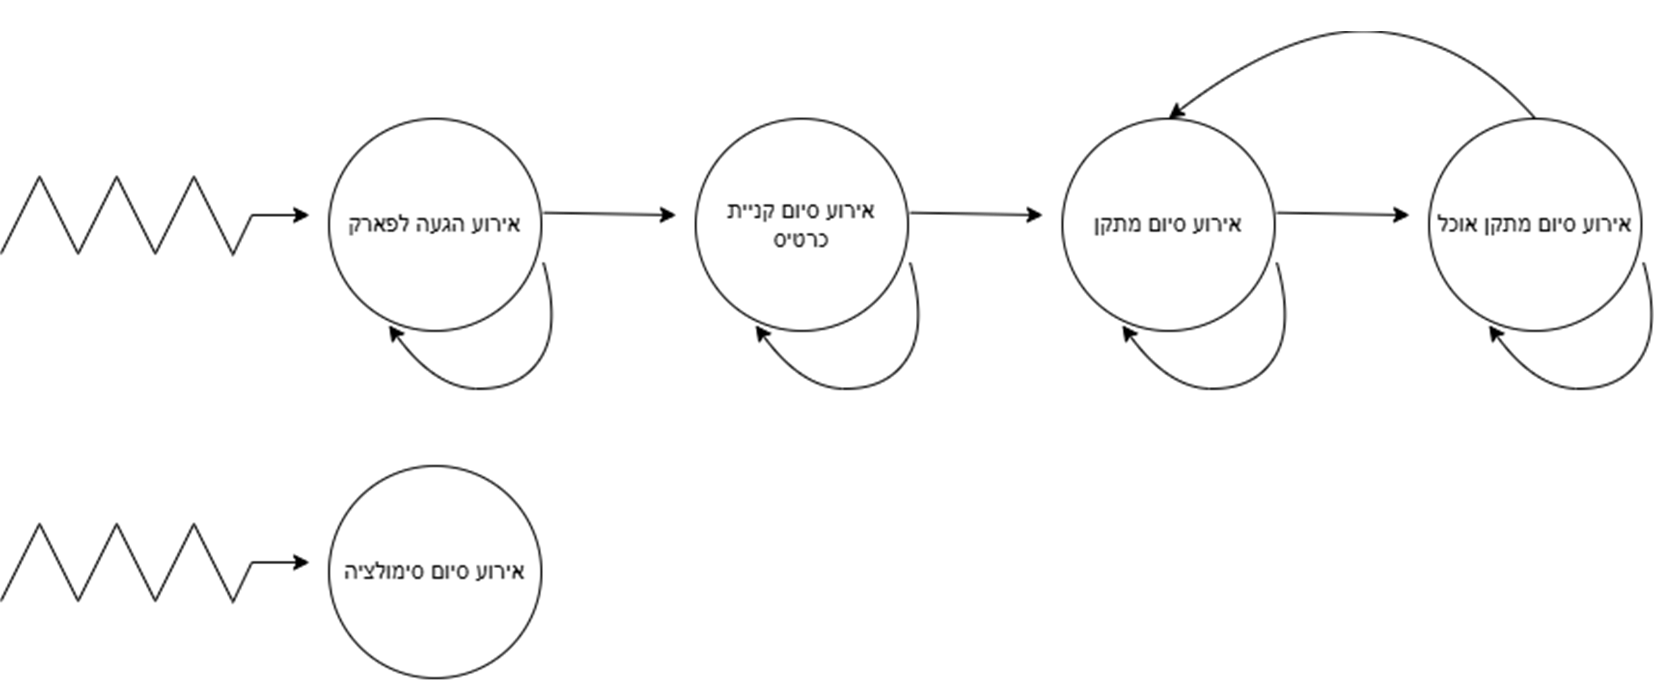

 <div dir="rtl" style="text-align: right;">


**אירוע הגעת מבקר**

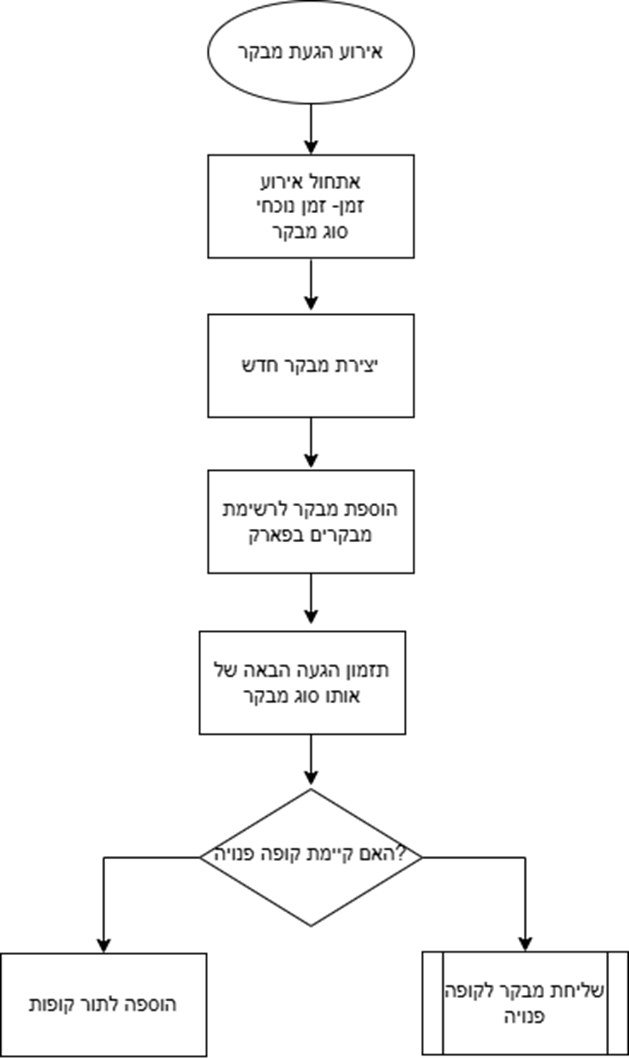

 <div dir="rtl" style="text-align: right;">


**אירוע סיום מתקן אוכל**

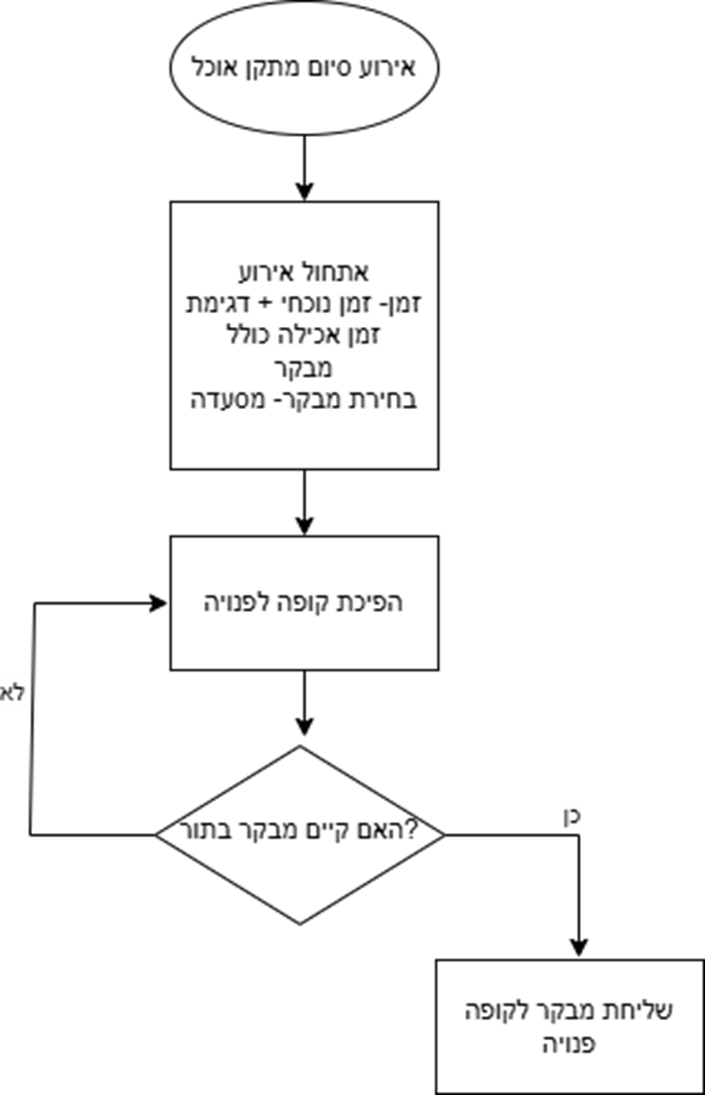

 <div dir="rtl" style="text-align: right;">


**אירוע סיום מתקן**

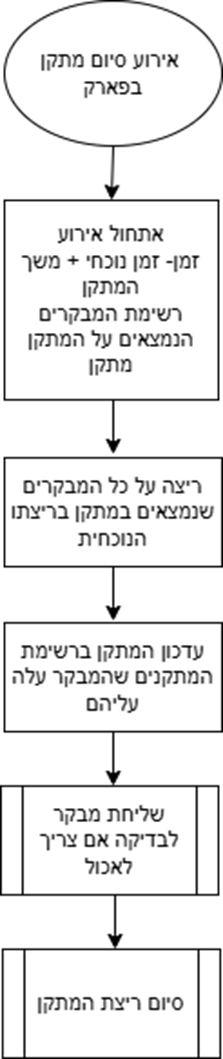

<div dir="rtl" style="text-align: right;">

 #  אירועים

</div>





<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע**
<div dir="rtl" style="text-align: right; font-size: 16\px;">


בקטע זה נגדיר את מחלקת האב של כל האירועים שמתרחשים בפארק במהלך הסימולציה. כל פעולה עיקרית שקשורה במבקר כמו הגעה לפארק, סיום רכיבה על מתקן, עזיבת תור או יציאה מהפארק, מיוצגת כאירוע מסוג שונה.
מחלקת האירוע כוללת את זמן ההתרחשות של האירוע ואת המבקר שאליו הוא קשור.

המחלקה מופשטת, וממנה נגזרות כל מחלקות האירועים הספציפיות בפרויקט.
האירועים מתוזמנים ונשמרים ביומן אירועים שמסודר לפי סדר זמנים, כך שבכל רגע יתבצע האירוע הקרוב ביותר בזמן.
</div>


In [ ]:
from typing import Optional

### Event Class ###
class Event(ABC):
    def __init__(self, time: float, visitor: Optional[Visitor]):
        self.time = time
        self.visitor = visitor

    def __lt__(self, other):  # Enables comparison between events based on time
        return self.time < other.time

    @abstractmethod
    def handle(self, Simulation):  # Each subclass must implement how it handles the event
        print("Handle method must be implemented by subclasses")
        pass


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע הגעה לפארק**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מייצגת את הרגע שבו מבקר חדש נכנס לפארק. עם הפעלת האירוע, נוצר עבור המבקר מופע חדש הכולל את מאפייניו (סוג מבקר, גודל קבוצה, ועוד), והוא מתווסף לרשימת המבקרים הפעילים בפארק.

בנוסף, מתוזמן מראש האירוע הבא של אותו סוג מבקר. כלומר, כבר בשלב זה, בסימולציה עצמה, מחשבים מתי ייכנס המבקר הבא מאותו סוג, בהתאם להתפלגות שהוגדרה לו.

לבסוף, האירוע בודק האם קיימת קופה פנויה. אם כן, המבקר נשלח מיד לקופה. אם לא, הוא מצטרף לתור ההמתנה לקופות הכניסה.


</div>



In [ ]:
### Arrival Event Class ###
class ArrivalEvent(Event):
    def __init__(self, time: float, visitor_type: VisitorType):  # Initialize the class
        super().__init__(time, visitor = Visitor(visitor_type=visitor_type))  # Create a new visitor
        self.visitor_type = visitor_type

    def handle(self, simulation):
        # self.visitor = Visitor(visitor_type=self.visitor_type)
        self.visitor.entry_time = self.time
        simulation.visitors.append(self.visitor)  # Add the visitor to the list of visitors

        # Schedule next arrival of the same visitor type
        next_arrival_delay = self.visitor_type.get_arrival_algorithm()  # Get time difference based on visitor type
        next_arrival_time = self.time + next_arrival_delay  # Add time difference to current time
        if next_arrival_time < simulation.simulation_end_time:  # If the next arrival time is before simulation ends
            simulation.schedule_event(ArrivalEvent(next_arrival_time, self.visitor_type))  # Add the next arrival event

        # Handle ticket booth logic
        if simulation.boothAvailable():  # Check if a booth is available
            simulation.assign_to_booth(self.time, self.visitor)  # Send visitor to available booth
        else:  # If no booth is available
            simulation.booth_queue.append((self.time, self.visitor))  # Add visitor to booth waiting list


<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע עזיבת תור**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מתארת את הסיטואציה שבה מבקר עומד בתור למתקן אך עובר זמן רב מדי  ולכן מחליט לעזוב את התור מבלי לעלות על המתקן.
כאשר האירוע מתרחש, נבדק אם המבקר עדיין נמצא בתור למתקן. אם כן, הוא מוסר מהרשימה, והמתקן אליו ניסה להיכנס מתווסף לרשימת המתקנים שעליהם המבקר ויתר. פעולה זו תסייע להימנע מלשלוח את אותו מבקר שוב לאותו מתקן בעתיד. לאחר מכן, המבקר ינסה לבחור מתקן חלופי.

</div>



In [ ]:
### Leave Queue Event Class ###
class LeaveQueueEvent(Event):
    def __init__(self, leave_time: float, visitor: Visitor, ride: Ride):  # Class initialization
        super().__init__(leave_time, visitor)
        self.ride = ride

    def handle(self, simulation):
        if self.visitor in self.ride.queue:  # If the visitor is still in the queue – remove them
            self.ride.queue.remove(self.visitor)
            self.visitor.add_to_queue(self.ride)  # Mark the ride as abandoned
            simulation.choose_ride(self.time, self.visitor)  # Try to choose another ride

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע סיום מתקן אוכל**

<div dir="rtl" style="text-align: right; font-size: 16\px;">


אירוע זה מתרחש לאחר שמבקר סיים את שלב התשלום וההזמנה באחת ממסעדות הפארק (נקניקיות, פלאפל או אוכל סיני).

בשלב זה, נבדק האם קיימים מבקרים נוספים שממתינים בתור לאותה מסעדה. אם כן, המבקר הבא בתור נשלח לתחנת השירות (כל עוד יש עמדת תשלום פנויה), ונוצר עבורו אירוע חדש של אכילה.

האירוע גם מדמה את זמן האכילה של המבקר שזה עתה סיים להזמין

לאחר סיום האכילה, המבקר חוזר למסלולו בפארק ונשלח לבחירת מתקן נוסף.

</div>



In [ ]:
### Restaurant End Event Class ###
from typing import Optional

class RestaurantEndEvent(Event):
    def __init__(self, time: float, visitor: Optional[Visitor], choose: str, simulation: ParkSimulation, sampler):
        super().__init__((time + simulation.time_food(choose, sampler)), visitor)
        self.simulation = simulation
        self.sampler = sampler
        self.choose = choose

    def handle(self, simulation):
        arrival_time = 0.0
        finish_time = self.time + simulation.eating_food(self.choose, self.sampler)
        if self.choose == "HotDog":  # Arrived at the hotdog stand
            simulation.HotDog_busy -= 1  # Mark the hotdog register as available
            if simulation.HotDog_queue:  # If there is someone in the hotdog queue
                arrival_time, next_visitor = simulation.HotDog_queue.pop(0)  # Take the first visitor in the queue
                simulation.HotDog_busy += 1
                simulation.check_food(self.time , next_visitor, self.choose)

        elif self.choose == "Falafel":  # Arrived at the falafel stand
            simulation.Falafel_busy = False  # Mark the falafel register as available
            if simulation.Falafel_queue:  # If there is someone in the falafel queue
                arrival_time, next_visitor = simulation.Falafel_queue.pop(0)  # Take the first visitor in the queue
                simulation.Falafel_busy = True
                simulation.check_food(self.time, next_visitor, self.choose)

        else:  # Arrived at the Chinese food stand
            simulation.Chinese_busy = False  # Mark the Chinese register as available
            if simulation.Chinese_queue:  # If there is someone in the Chinese food queue
                arrival_time, next_visitor = simulation.Chinese_queue.pop(0)  # Take the first visitor in the queue
                simulation.Chinese_busy = True
                simulation.check_food(self.time, next_visitor, self.choose)

        simulation.choose_ride(finish_time, self.visitor)  # Send the visitor to the next ride in the park

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע סיום קופות כניסה**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מייצגת את הרגע שבו מבקר סיים את תהליך הרכישה בקופת הכניסה לפארק, והקופה הופכת לפנויה.

כאשר האירוע מופעל, מתעדכן מספר הקופות הפעילות, ונבדק האם קיימים מבקרים הממתינים בתור. אם כן, המבקר הראשון בתור נשלף ומועבר לעמדת קופה פנויה.

לאחר מכן, המבקר ממשיך במסלולו ונשלח לבחירת מתקן ראשון בפארק.

</div>



In [ ]:
### Booth Departure Event Class ###
class BoothDepartureEvent(Event):
    def __init__(self, time: float, visitor: Visitor):  # Class initialization
        super().__init__(time, visitor)

    def handle(self, simulation):
        simulation.booth_busy -= 1  # Mark a booth as available
        if simulation.booth_queue:  # If there is a visitor in the booth queue
            arrival_time, next_visitor = simulation.booth_queue.pop(0)  # Take the first visitor in the queue
            simulation.assign_to_booth(self.time, next_visitor)  # Send the next visitor to an available booth
        simulation.choose_ride(self.time, self.visitor)  # Send the visitor to a ride in the park

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע סיום מתקן**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מתארת את סיום הפעולה של מתקן כלשהו בפארק, כלומר הרכיבה על המתקן הסתיימה וכל המבקרים שהשתתפו בה יורדים מהמתקן.
כאשר האירוע מתרחש, המחלקה מבצעת ריצה על כל המבקרים ששהו במתקן, ומעדכנת את רשימת המתקנים שעליהם הם עלו.

לאחר מכן, מתבצעת בדיקה האם הגיע הזמן עבור כל אחד מהמבקרים לגשת לאזור האוכל. אם כן, הם נשלחים למסעדה מתאימה. אם לא, הם ממשיכים לבחירת מתקן נוסף.
לבסוף, המתקן מסיים את הריצה הנוכחית ומתפנה לשימוש מחודש על ידי מבקרים אחרים.

</div>



In [ ]:
### Ride End Event Class ###
class RideEndEvent(Event):
    def __init__(self, time: float, visitors: list[Visitor], ride: Ride):
        super().__init__(time + float(ride.get_ride_duration()), None)
        self.ride = ride
        self.visitors: List[Visitor] = visitors

    def handle(self, simulation):
        for vis in self.visitors:  # Iterate over all visitors currently on the ride
            vis.rides_taken.append(self.ride)  # Update the ride in the list of completed rides for the visitor
            simulation.check_food(self.time, vis)  # Check if the visitor wants to eat now and where
        self.ride.end_ride()  # End the current ride session

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע יציאה מהפארק**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מתארת את הרגע שבו מבקר עוזב את הפארק. בעת הפעלת האירוע, נשמר זמן היציאה של המבקר, מחושב הזמן הכולל ששהה בפארק, והמופע שלו מוסר מרשימת המבקרים הפעילים.


</div>



In [ ]:
### Park Exit Event Class ###
class ExitEvent(Event):
    def __init__(self, time : float, visitor : Visitor):
        super().__init__(time, visitor)
        visitor.exit_time = time
        self.total_time = time - visitor.entry_time  # Calculate total time the visitor spent in the park

    def handle(self, simulation):
        simulation.visitors.remove(self.visitor)  # Remove the visitor from the park's visitor list

<div dir="rtl" style="text-align: right;">
<div dir="rtl" style="text-align: right; font-size: 25\px;">

**מחלקת אירוע סיום סימולציה**

<div dir="rtl" style="text-align: right; font-size: 16\px;">

מחלקה זו מייצגת את הרגע שבו מסתיימת הסימולציה כולה. אירוע זה מופעל בסוף יום סימולציה  ומטרתו לאפס את כל המשתנים והמבנים שנצברו במהלך הריצה.
האירוע מנקה את רשימת האירועים ומחזיר את הסימולציה למצב התחלתי, כך שניתן יהיה להריץ אותה מחדש במדויק ביום הבא.


</div>



In [ ]:
### Simulation End Event Class ###
class SimulationEndEvent(Event):
    def __init__(self, time: float):
        super().__init__(time, None)  # No actual visitor needed for the end-of-simulation event

    def handle(self, simulation):
        simulation.initialize_park_vars()  # Clear all upcoming events and reinitialize park state

<div dir="rtl" style="text-align: right;">

 #  יצירת סימולציה - לונה פארק

 <div dir="rtl" style="text-align: right; font-size: 16px;">

בקטע זה נגדיר את מחלקת הסימולציה הראשית, אשר מריצה את כל מהלך הפעילות בפארק-  מהגעת המבקרים, דרך ניהול התורים והמתקנים, ועד ניתוח תוצאות ביצועיות לאחר כל הרצה.

המחלקה מריצה את הסימולציה על פני יום הרצה, מתזמנת את כל האירועים בפארק,

</div>

 <div dir="rtl" style="text-align: right; font-size: 16px;">

בקטע הקוד הזה אנחנו מפעילים את הסימולציה של הפארק עם הגדרות קבועות, כדי לקבל תוצאות אחידות בכל הרצה.

הסימולציה רצה 100 פעמים עם אותם תנאים
</div>

In [ ]:
from logging import exception
import numpy as np
import random
import heapq
import math
from scipy import stats
from typing import List

class ParkSimulation:
    def __init__(self, numOfBooth, sampler: Sampler, simulation_minutes=720, n0 = 10, auto_ticketing=1.0,big_coaster_capacity=24,ferris_wheel_capacity=40,small_coaster_capacity=16,extra_restaurant_station=1, river_tubing_capacity=15):
        self.simulation_end_time = simulation_minutes  # Set simulation end time
        self.sampler = sampler
        self.numOfBooth = numOfBooth  # Initialize number of entrance booths
        self.n0 = n0
        self.end_rides_per_visitors = []
        self.avarage_stay_time = []
        self.auto_ticketing = auto_ticketing
        self.big_coaster_capacity = big_coaster_capacity
        self.ferris_wheel_capacity = ferris_wheel_capacity
        self.small_coaster_capacity = small_coaster_capacity
        self.extra_restaurant_station = extra_restaurant_station
        self.river_tubing_capacity = river_tubing_capacity
        self.initialize_park_vars()

    def initialize_park_vars(self):
        self.clock = 0.0  # Initialize clock
        self.event_list = []  # Initialize event list
        heapq.heapify(self.event_list)  # Convert list to a heap
        self.visitors: list[Visitor] = [] # Initialize visitor list
        self.booth_busy = 0  # Number of busy entrance booths
        self.booth_queue = []  # Queue for entrance booths
        self.HotDog_busy = 0  # Number of busy hotdog cashiers
        self.HotDog_queue = []  # Queue for hotdog cashier
        self.Falafel_busy = False  # Falafel cashier busy flag
        self.Falafel_queue = []  # Queue for falafel cashier
        self.Chinese_busy = False  # Chinese cashier busy flag
        self.Chinese_queue = []  # Queue for Chinese cashier
        self.count_EndRide = 0
        self.count_Arrival = 0
        self.count_Exit = 0
        self.end_rides_per_visitors_daily = 0
        self.num_visitors_completed_all_rides = 0
        self.sum_of_visitors_stay_time = 0
        self.avarage_stay_time_daily = 0

        # Initialize all rides
        self.all_rides = [
            SmallRollerCoaster(self.small_coaster_capacity),
            FerrisWheel(sampler, self.ferris_wheel_capacity),
            RiverTubing(sampler, self.river_tubing_capacity),
            BumperCars(sampler),
            BigRollerCoaster(sampler, self.big_coaster_capacity),
            FreeFall(sampler),
            FlippingBoat()
        ]
        self.extreme_rides: List[Ride] = []
        self.family_rides: List[Ride] = []
        for ride in self.all_rides:
            if ride.category in ["extreme", "both"]:
                self.extreme_rides.append(ride)  # Add extreme rides
            if ride.category in ["family", "both"]:
                self.family_rides.append(ride)  # Add family rides

        self.initialize_arrivals()  # Initialize visitor arrival queues
    # Running the simulation
    def run(self):
        for i in range(self.n0):
            print(f"\n\n--------------------------------------day num: {i+1}  ---------------------------------------")
            print(f"Starting ParkSimulation with {self.numOfBooth} booths for {self.simulation_end_time} Minutes")
            count = 0
            while (self.event_list and self.clock <= self.simulation_end_time) or count == 0:  # As long as there are upcoming events and the current time is less than the simulation end time
                event = self.get_next_event()
                if event is None:  # Stop if there are no upcoming events
                    break
                self.clock = event.time  # Advance the clock to the time of the next event

                if isinstance(event, RideEndEvent):
                    self.count_EndRide += 1  # Count the number of ride activations
                    #############print(f"{self.clock} & {count} - Handling {event.__class__.__name__} ") #- להדפיס את כל האירועים

                elif isinstance(event, ExitEvent):
                    self.num_visitors_completed_all_rides += 1  # Count how many visitors exited the park
                    self.sum_of_visitors_stay_time += event.total_time  # Accumulate the total visitor stay time in the park
                    #############print(f"{self.clock} & {count} - Handling {event.__class__.__name__} with a {event.visitor.visitor_type.__class__.__name__} of {event.visitor.group_size} id: {event.visitor.id} eat: {event.visitor.when_food}") #- Print all events

                elif isinstance(event, ArrivalEvent):
                    self.count_Arrival += 1  # Count how many visitors arrived at the park

                #############elif event.visitor is not None:
                    #############print(f"{self.clock} & {count} - Handling {event.__class__.__name__} with a {event.visitor.visitor_type.__class__.__name__} of {event.visitor.group_size} id: {event.visitor.id} eat: {event.visitor.when_food}") #- Print all events

                event.handle(self)
                if not isinstance(event, SimulationEndEvent):  # Print all events
                    count += 1  # Print all events

            print(f"Ending Simulation day num: {i+1}!")
            self.remove_remaining_visitors()
            self.end_rides_per_visitors_daily = self.count_EndRide / self.count_Arrival  # Calculate metric #1
            self.avarage_stay_time_daily = self.sum_of_visitors_stay_time / self.num_visitors_completed_all_rides  # Calculate metric #2

            # Print performance metrics
            print("------ Performance Metrics for Simulation Day ------")
            print(f"Metric #1 – Ride activations per visitor: {self.end_rides_per_visitors_daily:.4f}")
            print(f"    (Total ride activations: {self.count_EndRide}, Total visitors arrived: {self.count_Arrival})")

            print(f"Metric #2 – Average visitor stay time: {self.avarage_stay_time_daily:.4f} minutes")
            print(f"    (Total stay time of all visitors: {self.sum_of_visitors_stay_time:.4f}, Visitors who completed their visit: {self.num_visitors_completed_all_rides})")

            self.schedule_event(SimulationEndEvent(self.simulation_end_time))

            # Add metrics to daily results lists
            self.end_rides_per_visitors.append(self.end_rides_per_visitors_daily)
            self.avarage_stay_time.append(self.avarage_stay_time_daily)

    def schedule_event(self, event: Event):  # Add an event to the event calendar
        heapq.heappush(self.event_list, event)

    def get_next_event(self):  # Get the next event from the event calendar
        if self.event_list:
            return heapq.heappop(self.event_list)
        return None

    def boothAvailable(self):  # Check if there is an available entrance booth
        return self.booth_busy < self.numOfBooth

    def hotdogAvilable(self):  # Check if there is an available counter at the hotdog restaurant
        return self.HotDog_busy < self.extra_restaurant_station

    def assign_to_booth(self, time: float, visitor: Visitor):  # Assign a visitor to an available booth
        self.booth_busy += 1  # Occupy an available booth
        service_time = 0.0
        while service_time <= 0.0:
            service_time = self.sampler.NormalSamplingAlgorithm(3, 1 * self.auto_ticketing)  # Sample service time
        departure_time = time + service_time  # Calculate end of service time
        self.schedule_event(BoothDepartureEvent(departure_time, visitor))  # Add to the event calendar

    def remove_remaining_visitors(self):  # Remove all remaining visitors from the park at the end of the day and count them
        for v in self.visitors:
            self.sum_of_visitors_stay_time += 720.0 - v.entry_time
            self.num_visitors_completed_all_rides += 1

    def initialize_arrivals(self):  # Create arrival queues for each visitor type
        visitor_types = [FamilyVisitor(self.sampler), TeenVisitor(self.sampler), CoupleVisitor(self.sampler), IndividualVisitor(self.sampler)]  # Define all available visitor types
        for visitor_type in visitor_types:  # Iterate through all visitor types
            first_arrival_time = visitor_type.entry_window[0] + visitor_type.get_arrival_algorithm()  # Calculate first arrival time plus sampled delay
            arrival_event = ArrivalEvent(first_arrival_time, visitor_type)
            if first_arrival_time < self.simulation_end_time:  # Check if arrival time is before park closing
                self.schedule_event(ArrivalEvent(first_arrival_time, visitor_type))  # Add event to the calendar

    def choose_ride(self, time, visitor):  # Direct a visitor to choose a ride
        ride_list = []  # Create a list of rides
        type = True

        # Check allowed rides based on visitor type
        if isinstance(visitor.visitor_type, FamilyVisitor):  # Rules for families
            ride_list = self.family_rides
        elif isinstance(visitor.visitor_type, TeenVisitor):  # Rules for teens
            ride_list = self.extreme_rides
        elif isinstance(visitor.visitor_type, CoupleVisitor):  # Rules for couples
            ride_list = self.all_rides
        elif  isinstance(visitor.visitor_type, IndividualVisitor):  # Rules for individuals
            ride_list = self.all_rides
            type = False
        else:  # If visitor is not from a defined type
            pass

        best_ride = None  # Initialize suitable ride

        if type:
            for ride in ride_list:  # Iterate through ride types
                if isinstance(visitor.visitor_type, TeenVisitor):  # Rules for teens
                    if (ride not in visitor.rides_taken) and (ride not in visitor.queued_rides):  # If the ride hasn't been taken and not abandoned
                        best_ride = ride
                        leave_time = time + visitor.visitor_type.max_wait_time  # Schedule potential queue leave
                        self.schedule_event(LeaveQueueEvent(leave_time, visitor, best_ride))  # Add leave event to calendar
                        break

                    if ride in visitor.queued_rides:  # If ride queue was previously abandoned
                        best_ride = ride
                        break

                elif isinstance(visitor.visitor_type, CoupleVisitor):  # Rules for couples
                    if (ride not in visitor.rides_taken) and (ride not in visitor.queued_rides):  # If the ride hasn't been taken and not abandoned
                        best_ride = ride
                        leave_time = time + visitor.visitor_type.max_wait_time  # Schedule potential queue leave
                        self.schedule_event(LeaveQueueEvent(leave_time, visitor, best_ride))  # Add leave event to calendar
                        break

                if isinstance(visitor.visitor_type, FamilyVisitor):  # Rules for families
                    if ride not in visitor.rides_taken:  # If the ride hasn't been taken yet
                        best_ride = ride

        else:  # Rules for individuals
            min_wait_time = float('inf')  # Initialize minimum to infinity
            currnt_ride = None
            for ride in ride_list:
                queue_size = sum(visitor.group_size for vis in ride.queue)  # Check queue length
                wait_time = (queue_size / ride.capacity) * ride.get_ride_duration()  # Estimate wait time

                if wait_time < min_wait_time:  # Find ride with the shortest wait time
                    min_wait_time = wait_time
                    currnt_ride = ride
            best_ride = currnt_ride

        if best_ride:  # If a suitable ride was found
            best_ride.add_to_queue(visitor)
            if best_ride.start_ride():
                self.schedule_event(RideEndEvent(time, best_ride.current_riders, best_ride))  # Schedule ride end event
        else:
            self.schedule_event(ExitEvent(time, visitor))  # Schedule exit event if no ride found


    def check_food(self, time: float, visitor: Visitor, choose=None):  # Check if it's time for the visitor to eat and add them to the food payment queue
        if len(visitor.rides_taken) == visitor.when_food:  # If it's the time for the visitor to eat
            choose = choose if choose else self.sampler.sampleFoodCourtAlgorithm()  # Determine food type
            match choose:
                case "HotDog":
                    if not self.hotdogAvilable():
                        self.HotDog_queue.append((time, visitor))  # Add visitor to hotdog queue
                        return
                    self.HotDog_busy += 1

                case "Falafel":
                    if self.Falafel_busy:
                        self.Falafel_queue.append((time, visitor))  # Add visitor to falafel queue
                        return
                    self.Falafel_busy = True

                case "Chinese":
                    if self.Chinese_busy:
                        self.Chinese_queue.append((time, visitor))  # Add visitor to Chinese food queue
                        return
                    self.Chinese_busy = True
            #############print(f"-----[choose_food] VisitorID {visitor.id} chose {choose} at time {time}")  # איזה מסעדה המבקר בחר
            self.schedule_event(RestaurantEndEvent(time, visitor, choose, self, sampler=sampler))  # Add event to calendar
        else:
            self.choose_ride(time, visitor)  # Send visitor to another ride in the park

    def time_food(self, choose: str, sampler: Sampler):  # Sample service and payment time at a food court
        if choose == "HotDog":  # Visitor chose the hotdog stand
            restaurant = HotdogRestaurant(sampler)
        elif choose == "Falafel":  # Visitor chose the falafel stand
            restaurant = FalafelRestaurant(sampler)
        else:  # Visitor chose the Chinese stand
            restaurant = ChineseRestaurant(sampler)
        next_service_time = restaurant.get_ServiceTime_algorithm() + restaurant.get_PaymentTime_algorithm()  # Total service + payment time
        return next_service_time

    def eating_food(self, choose: str, sampler: Sampler):  # Sample eating time at a food court
        if choose == "HotDog":  # Visitor chose the hotdog stand
            restaurant = HotdogRestaurant(sampler)
        elif choose == "Falafel":  # Visitor chose the falafel stand
            restaurant = FalafelRestaurant(sampler)
        else:  # Visitor chose the Chinese stand
            restaurant = ChineseRestaurant(sampler)
        eating_time = restaurant.get_EatingTime_algorithm()
        return eating_time


    def calculate_confidence_interval(self, data, alffa=0.1, gamma=0.1, verbose=True, label=None):
        n = len(data)
        mean = np.mean(data)
        std = np.std(data, ddof=1)  # Sample standard deviation
        t_value = stats.t.ppf(1 - alffa / 2, df=n - 1)  # t-distribution critical value

        margin_error = t_value * std / np.sqrt(n)  # Margin of error for the CI
        ci = (mean - margin_error, mean + margin_error)  # Confidence interval

        gamma_prime = gamma / (1 + gamma)  # Convert gamma to bound for comparison
        relative_bound = gamma_prime * mean
        passed = margin_error <= relative_bound  # Check if CI width meets requirement

        if verbose:
            if label:
                print(f"\n {label}")
                print(f"  → Mean: {mean:.4f}")
                print(f"  → CI: ({ci[0]:.4f}, {ci[1]:.4f})  | Half-width: ±{margin_error:.4f}")
                print(f"  → Relative threshold: {relative_bound:.4f}")
                print(f"  → CI {'meets' if passed else 'does NOT meet'} the relative precision criterion.")

        return {"mean": mean, "std": std, "t": t_value, "n": n, "margin_error": margin_error, "ci": ci, "relative_bound": relative_bound, "passed": passed}


def run_until_precision(sim_class, sampler, alpha=0.1, gamma=0.1, min_n0=10, max_n0=300, step=5, **sim_kwargs):
    n0 = min_n0
    while n0 <= max_n0:
        print(f"\n Running simulation with n0 = {n0}")
        sim = sim_class(sampler=sampler, n0=n0, **sim_kwargs)
        sim.run()

        # Evaluate confidence intervals for both performance metrics
        result1 = sim.calculate_confidence_interval(
            sim.end_rides_per_visitors, alffa=alpha, gamma=gamma, verbose=True, label="🎢 Ride activations")
        result2 = sim.calculate_confidence_interval(
            sim.avarage_stay_time, alffa=alpha, gamma=gamma, verbose=True, label="⏱ Avg stay time")

        # If both metrics meet precision criteria, return the simulation
        if result1["passed"] and result2["passed"]:
            print(f"\n Reached required precision with {n0} runs.\n")
            return sim

        print(f" Precision not met. Increasing n0 to {n0 + step}")
        n0 += step

    raise ValueError(f" Did not reach desired precision within {max_n0} runs.")


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
sampler = Sampler()
sim = run_until_precision(sim_class=ParkSimulation, sampler=sampler, numOfBooth=2, simulation_minutes=720, extra_restaurant_station=1, min_n0=10, max_n0=100, step=10)

#נגדיר מינימום של 10 תצפיות על מנת שרמת המובהקות ורווח הסמך יהיו אמינים##


 Running simulation with n0 = 10


--------------------------------------day num: 1  ---------------------------------------
Starting ParkSimulation with 2 booths for 720 Minutes
Ending Simulation day num: 1!
------ Performance Metrics for Simulation Day ------
Metric #1 – Ride activations per visitor: 1.2819
    (Total ride activations: 623, Total visitors arrived: 486)
Metric #2 – Average visitor stay time: 241.4135 minutes
    (Total stay time of all visitors: 117326.9562, Visitors who completed their visit: 486)


--------------------------------------day num: 2  ---------------------------------------
Starting ParkSimulation with 2 booths for 720 Minutes
Ending Simulation day num: 2!
------ Performance Metrics for Simulation Day ------
Metric #1 – Ride activations per visitor: 1.1064
    (Total ride activations: 603, Total visitors arrived: 545)
Metric #2 – Average visitor stay time: 258.2547 minutes
    (Total stay time of all visitors: 140748.8136, Visitors who completed their 

<div dir="rtl" style="text-align: right;">

 #  מציאת חלופות

 <div dir="rtl" style="text-align: right; font-size: 16px;">


בקטע זה ביצענו בדיקה אוטומטית של כל שילובי החלופות האפשריים (בקבוצות של 2 או 3 חלופות), תחת מגבלה תקציבית של 100,000 ₪.
לכל שילוב שנבחר, ביצענו הרצת סימולציה של 30 ימי פעילות תוך התאמת פרמטרים בהתאם לחלופות – למשל קיצור זמן שירות בקופות, הגדלת קיבולת מתקנים או הוספת עמדת תשלום במסעדה.

לאחר כל הרצה נמדדו שני מדדים:

מספר הפעלות מתקנים למבקר - מדד שמעיד על עומס בפארק ועל כמות הפעלת המתקנים (הוצאה של הפארק) פר כניסת מבקרים (הכנסות).

זמן שהייה ממוצע של מבקר בפארק- ככל שהוא קצר יותר, כך  מתקיימים פחות תורים למתקנים ומדד שביעות רצון המבקרים עולה.

לבסוף, מיינו את כל התוצאות ובחרנו את שתי הקומבינציות הטובות ביותר, אלו שמצמצמות את שני המדדים גם יחד.


</div>



In [ ]:
from itertools import combinations

# Define all upgrade alternatives with their costs and parameter changes
alternatives = [
    {"name": "auto_ticketing", "cost": 40000, "params": {"auto_ticketing": 0.5}},
    {"name": "big_coaster_upgrade", "cost": 50000, "params": {"big_coaster_capacity": 32}},
    {"name": "ferris_upgrade", "cost": 45000, "params": {"ferris_wheel_capacity": 48}},
    {"name": "small_coaster_upgrade", "cost": 55000, "params": {"small_coaster_capacity": 24}},
    {"name": "river_tubing_upgrade", "cost": 25000, "params": {"river_tubing_capacity": 24}},
    {"name": "hotdog_extra_station", "cost": 35000, "params": {"extra_restaurant_station": 2}},
]

results = []

# Iterate over all possible combinations of 2 or 3 alternatives
for r in [2, 3]:
    for combo in combinations(alternatives, r):
        total_cost = sum(item["cost"] for item in combo)
        if total_cost > 100000:
            continue  # Skip combinations exceeding the budget

        combo_name = tuple(item["name"] for item in combo)
        print(f"\n\n\n---------------------------------------Simulation run with the alternative: {combo_name}--------------------------------------")

        # Combine all parameter changes from the selected alternatives
        combined_params = {}
        for item in combo:
            combined_params.update(item["params"])

        # Run the simulation with the selected configuration
        random.seed(seed)
        np.random.seed(seed)
        sampler = Sampler()
        sim = ParkSimulation(
            simulation_minutes=720,
            numOfBooth=2,
            sampler=sampler,
            n0=10,
            **combined_params
        )
        sim.run()

        # Compute average metrics for the simulation
        avg_rides = np.mean(sim.end_rides_per_visitors)
        avg_stay = np.mean(sim.avarage_stay_time)

        # Store the results for later comparison
        results.append({
            "combo": combo_name,
            "total_cost": total_cost,
            "avg_rides_per_visitor": avg_rides,
            "avg_stay_time": avg_stay,
        })

# Sort results by both ride activation rate and average stay time
sorted_results = sorted(results, key=lambda x: (x["avg_rides_per_visitor"], x["avg_stay_time"]))

# Print the top 2 combinations with best performance
print(f"\n\n\nThe best selected alternatives:")
for i, res in enumerate(sorted_results[:2], 1):
    print(f" \n#{i}: Combo: {res['combo']} (Cost: ${res['total_cost']})")
    print(f"    Avg rides/visitor: {res['avg_rides_per_visitor']:.4f}")
    print(f"    Avg stay time: {res['avg_stay_time']:.2f} minutes\n")





---------------------------------------Simulation run with the alternative: ('auto_ticketing', 'big_coaster_upgrade')--------------------------------------


--------------------------------------day num: 1  ---------------------------------------
Starting ParkSimulation with 2 booths for 720 Minutes
Ending Simulation day num: 1!
------ Performance Metrics for Simulation Day ------
Metric #1 – Ride activations per visitor: 1.3253
    (Total ride activations: 664, Total visitors arrived: 501)
Metric #2 – Average visitor stay time: 263.0906 minutes
    (Total stay time of all visitors: 131808.4103, Visitors who completed their visit: 501)


--------------------------------------day num: 2  ---------------------------------------
Starting ParkSimulation with 2 booths for 720 Minutes
Ending Simulation day num: 2!
------ Performance Metrics for Simulation Day ------
Metric #1 – Ride activations per visitor: 1.3437
    (Total ride activations: 649, Total visitors arrived: 483)
Metric #2 –